# Laboratorio 1 — Series de Tiempo
### Ingreso de viajeros internacionales a Guatemala (2009 – jun 2026)

**Curso:** CC3084 · Data Science · **Semestre II, 2026** · UVG

Este cuaderno contiene el **avance**: (1) análisis exploratorio general del conjunto de datos y
(2) análisis preliminar de dos series de tiempo. La entrega final ampliará el modelado
(ARIMA/SARIMA, Prophet, Holt-Winters, etc.) sobre las categorías seleccionadas.

**Categorías seleccionadas para el laboratorio completo:** *Vías de ingreso* y *Países de residencia*.

**Series analizadas en este avance:**
1. **Total mensual de viajeros internacionales** (definida como `Turista + Excursionista`, consistente en todo el período).
2. **Vía de ingreso Aérea**.

> **Nota de datos.** Los datos son de uso exclusivamente académico; no son cifras oficiales del INGUAT ni del IGM.

## 0. Instalación de dependencias

Si te falta alguna librería, descomenta y ejecuta la siguiente celda. Para el **avance** basta con
el stack de análisis (`pandas`, `numpy`, `matplotlib`, `seaborn`, `statsmodels`, `openpyxl`).
Las librerías de modelado (`pmdarima`, `prophet`) se usarán en la entrega final.

In [1]:
# !pip install numpy pandas matplotlib seaborn statsmodels scikit-learn openpyxl
# Para la entrega final:
# !pip install pmdarima prophet

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42
print("Entorno listo.")

Entorno listo.


## 1. Carga de datos y primer vistazo

El archivo `Base_Migracion_2009-2026jun.xlsx` tiene dos hojas: **`Datos`** (los registros) y
**`Notas`** (contexto metodológico). Trabajaremos con `Datos`, que está en **formato largo**:
una fila por combinación de mes × vía × frontera × país/agrupación × tipo de viajero, con la
cantidad en la columna `Viajero`.

In [3]:
ARCHIVO = "Base_Migracion_2009-2026jun.xlsx"

df = pd.read_excel(ARCHIVO, sheet_name="Datos")
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 161,036 filas x 13 columnas


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.00
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.00
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.00
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.00
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.00


In [4]:
# Tipos de dato y memoria
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Año                    161036 non-null  int64  
 1   Mes cod                161036 non-null  int64  
 2   Mes                    161036 non-null  str    
 3   Vía                    161036 non-null  str    
 4   Frontera               161036 non-null  str    
 5   País                   161036 non-null  str    
 6   Región                 161036 non-null  str    
 7   Región dos             161036 non-null  str    
 8   Regiones OMT           161036 non-null  str    
 9   MCEO                   161036 non-null  str    
 10  Agrupación Residencia  161036 non-null  str    
 11  Tipo de Viajero        161036 non-null  str    
 12  Viajero                161036 non-null  float64
dtypes: float64(1), int64(2), str(10)
memory usage: 16.0 MB


### 1.1 Construcción del índice temporal

Combinamos `Año` y `Mes cod` en una **fecha mensual** (primer día de cada mes, `freq='MS'`).
Esto nos permitirá luego agregar y construir las series de tiempo.

In [5]:
df["Fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes cod"], day=1))
print("Rango temporal:", df["Fecha"].min().date(), "->", df["Fecha"].max().date())
print("Meses únicos:", df["Fecha"].nunique(), "(esperado 210: ene-2009 a jun-2026)")

# Verificamos que NO haya huecos en el eje temporal mensual
rango_completo = pd.date_range(df["Fecha"].min(), df["Fecha"].max(), freq="MS")
faltantes = rango_completo.difference(df["Fecha"].unique())
print("Meses faltantes en el calendario:", len(faltantes))

Rango temporal: 2009-01-01 -> 2026-06-01
Meses únicos: 210 (esperado 210: ene-2009 a jun-2026)
Meses faltantes en el calendario: 0


## 2. Análisis de calidad: faltantes, duplicados y atípicos

*(Requisito 1e del enunciado.)*

### 2.1 Valores faltantes

In [6]:
faltantes_tabla = pd.DataFrame({
    "n_nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(2)
})
faltantes_tabla

,n_nulos,%_nulos
Año,0,0.00
Mes cod,0,0.00
Mes,0,0.00
Vía,0,0.00
Frontera,0,0.00
País,0,0.00
Región,0,0.00
Región dos,0,0.00
Regiones OMT,0,0.00
MCEO,0,0.00


### 2.2 Duplicados

Buscamos filas idénticas y también duplicados en la **clave lógica** (la combinación de dimensiones
que identifica un registro para un mismo mes). Un duplicado real provocaría doble conteo.

In [7]:
dup_exactos = df.duplicated().sum()

# Clave lógica COMPLETA: incluye 'Agrupación Residencia', la dimensión más fina.
clave_full = ["Fecha", "Vía", "Frontera", "País", "Tipo de Viajero", "Agrupación Residencia"]
dup_full = df.duplicated(subset=clave_full).sum()

# Clave SIN 'Agrupación Residencia': revela registros que solo difieren en esa dimensión.
clave_reducida = ["Fecha", "Vía", "Frontera", "País", "Tipo de Viajero"]
dup_reducida = df.duplicated(subset=clave_reducida).sum()

print(f"Duplicados exactos (fila completa): {dup_exactos}")
print(f"Duplicados en la clave lógica completa {clave_full}: {dup_full}")
print(f"'Duplicados' si se ignora 'Agrupación Residencia': {dup_reducida}")

# Inspeccionamos esos casos: ¿son doble conteo o un desglose más fino?
mask_dup = df.duplicated(subset=clave_reducida, keep=False)
ejemplo = (df[mask_dup]
           .sort_values(clave_reducida)
           [clave_reducida + ["Región dos", "Agrupación Residencia", "Viajero"]])
print(f"\nRegistros involucrados: {mask_dup.sum()} (en {df[mask_dup].groupby(clave_reducida).ngroups} grupos)")
print("¿Difiere 'Región dos' dentro de un grupo?:",
      (df[mask_dup].groupby(clave_reducida)["Región dos"].nunique() > 1).any())
ejemplo.head(6)

Duplicados exactos (fila completa): 0
Duplicados en la clave lógica completa ['Fecha', 'Vía', 'Frontera', 'País', 'Tipo de Viajero', 'Agrupación Residencia']: 0
'Duplicados' si se ignora 'Agrupación Residencia': 22



Registros involucrados: 42 (en 20 grupos)
¿Difiere 'Región dos' dentro de un grupo?: False


,Fecha,Vía,Frontera,País,Tipo de Viajero,Región dos,Agrupación Residencia,Viajero
130128,2020-12-01,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Europa,Europa,3.00
130129,2020-12-01,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Europa,Resto del Mundo,1.00
131981,2021-05-01,Aérea,01 La Aurora,Federación de Rusia,Turista,Europa,Europa,44.00
131982,2021-05-01,Aérea,01 La Aurora,Federación de Rusia,Turista,Europa,Resto del Mundo,223.00
132717,2021-06-01,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Europa,Europa,4.00
132718,2021-06-01,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Europa,Resto del Mundo,1.00


**Interpretación (duplicados).** No hay **ningún** duplicado real: con la clave lógica completa
(incluyendo `Agrupación Residencia`) el conteo es **0**. Los ~20 casos que aparecerían al ignorar
esa columna **no son doble conteo**, sino un país repartido en dos agrupaciones de residencia
distintas (p. ej. *Colombia* dividida entre "Colombia" y "Otros Suramérica"). Como la `Región dos`
es idéntica dentro de cada grupo, **nuestras agregaciones por fecha, vía, país o región no se ven
afectadas**: al sumar, esas filas se combinan correctamente.

### 2.3 Valores atípicos de la medida `Viajero`

La columna `Viajero` trae **decimales** porque son estimaciones de encuesta expandidas (no
conteos exactos). Revisamos su distribución, ceros y valores extremos con un boxplot en escala
logarítmica (la variable es muy asimétrica).

count   161,036.00
mean        324.70
std       2,387.75
min           0.00
25%           2.00
50%           7.00
75%          38.89
max      92,336.04
Name: Viajero, dtype: float64

Filas con Viajero == 0: 54
Filas con Viajero < 0 : 0


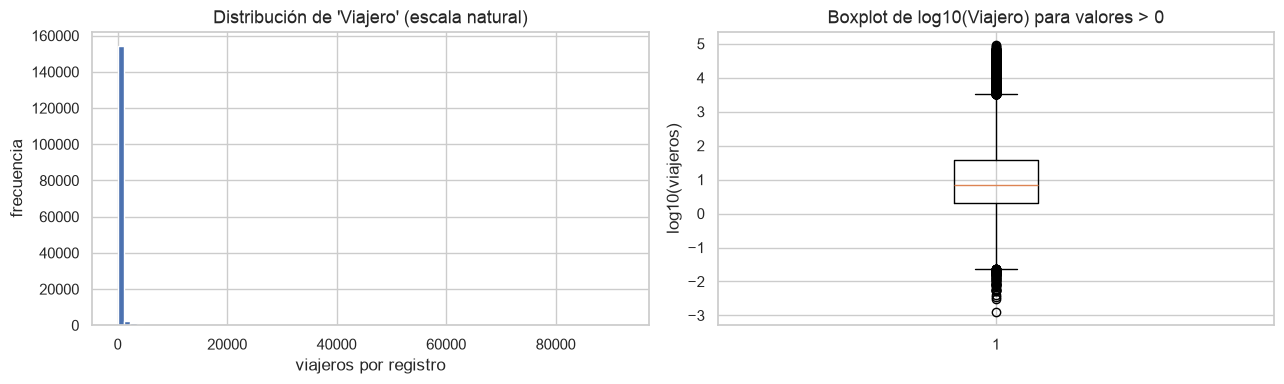

In [8]:
print(df["Viajero"].describe())
print("\nFilas con Viajero == 0:", (df["Viajero"] == 0).sum())
print("Filas con Viajero < 0 :", (df["Viajero"] < 0).sum())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(df["Viajero"], bins=80, color="#4c72b0")
ax[0].set_title("Distribución de 'Viajero' (escala natural)")
ax[0].set_xlabel("viajeros por registro"); ax[0].set_ylabel("frecuencia")

positivos = df.loc[df["Viajero"] > 0, "Viajero"]
ax[1].boxplot(np.log10(positivos), vert=True)
ax[1].set_title("Boxplot de log10(Viajero) para valores > 0")
ax[1].set_ylabel("log10(viajeros)")
plt.tight_layout(); plt.show()

**Interpretación (calidad).** El conjunto llega **muy limpio**: sin valores nulos, sin duplicados
exactos ni duplicados de clave lógica, y sin cantidades negativas. La medida `Viajero` es
fuertemente asimétrica (muchos registros pequeños de países/fronteras menores y pocos registros
muy grandes de mercados dominantes), por lo que los "atípicos" del boxplot **no son errores** sino
la cola natural de la distribución. Los decimales son esperados (estimaciones expandidas). No se
requiere imputación ni eliminación de filas para el análisis agregado.

## 3. Comportamiento temporal del número de viajeros

*(Requisito 1a.)* Agregamos el total mensual de viajeros (todos los tipos) para ver la evolución
global. Marcamos el inicio de la pandemia (mar-2020) y señalamos que **2026 es un año parcial**
(solo enero–junio), por lo que las comparaciones anuales de 2026 no son directas.

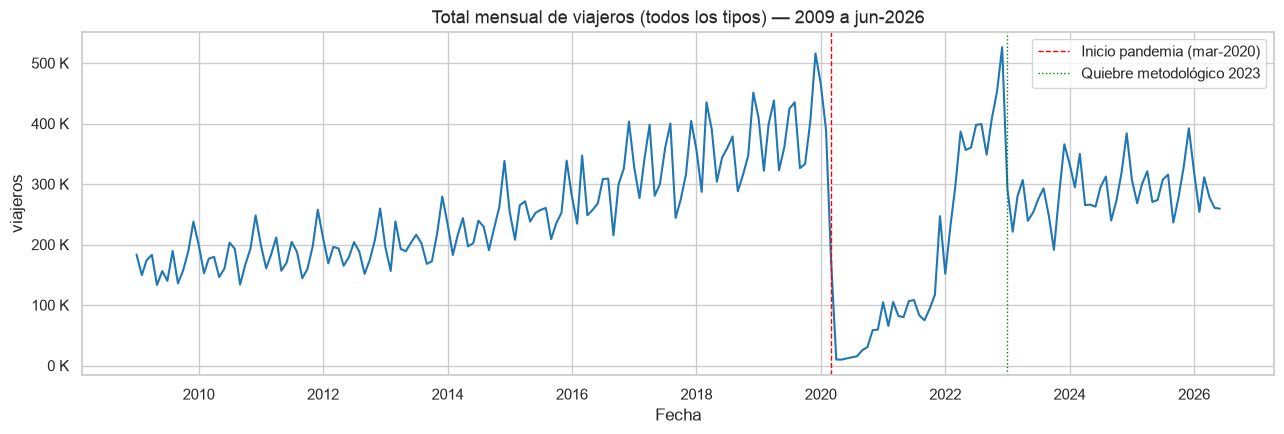

In [9]:
serie_total_bruta = df.groupby("Fecha")["Viajero"].sum()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(serie_total_bruta.index, serie_total_bruta.values, color="#1f77b4")
ax.axvline(pd.Timestamp("2020-03-01"), color="red", ls="--", lw=1, label="Inicio pandemia (mar-2020)")
ax.axvline(pd.Timestamp("2023-01-01"), color="green", ls=":", lw=1, label="Quiebre metodológico 2023")
ax.set_title("Total mensual de viajeros (todos los tipos) — 2009 a jun-2026")
ax.set_xlabel("Fecha"); ax.set_ylabel("viajeros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f} K"))
ax.legend(); plt.tight_layout(); plt.show()

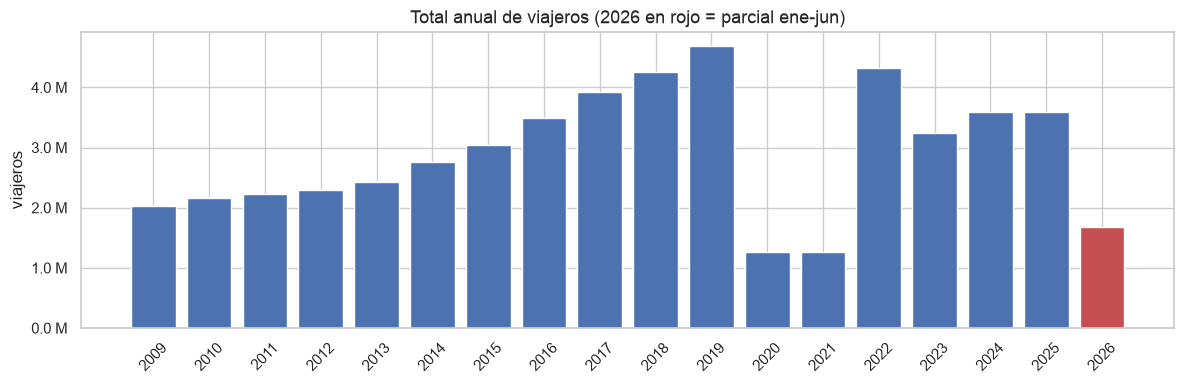

In [10]:
# Total ANUAL (marcamos 2026 como parcial)
tot_anual = df.groupby("Año")["Viajero"].sum()
fig, ax = plt.subplots(figsize=(12, 4))
colores = ["#c44e52" if a == 2026 else "#4c72b0" for a in tot_anual.index]
ax.bar(tot_anual.index.astype(str), tot_anual.values, color=colores)
ax.set_title("Total anual de viajeros (2026 en rojo = parcial ene-jun)")
ax.set_ylabel("viajeros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.1f} M"))
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

**Interpretación (temporal).** Se observan tres rasgos:
1. **Estacionalidad anual** clara (picos y valles que se repiten cada 12 meses).
2. El **colapso de la pandemia** en mar-2020 y el piso 2020–2021, con recuperación desde 2022.
3. El **quiebre metodológico de 2023** (línea verde), tras el cual la categoría "Viajero" se
   reclasifica; por eso más adelante trabajamos la serie total como `Turista + Excursionista`,
   que sí es comparable en todo el rango.

## 4. Composición por tipo de viajero y justificación de la serie total

El enunciado y las Notas advierten que la categoría **"Viajero"** (comercio fronterizo, tránsito)
cae artificialmente en 2023 por reclasificación, y que **"Cruceristas"** solo existe hasta 2022.
Para una serie comparable en todo el período se recomienda **Turista + Excursionista**. Lo
verificamos visualmente.

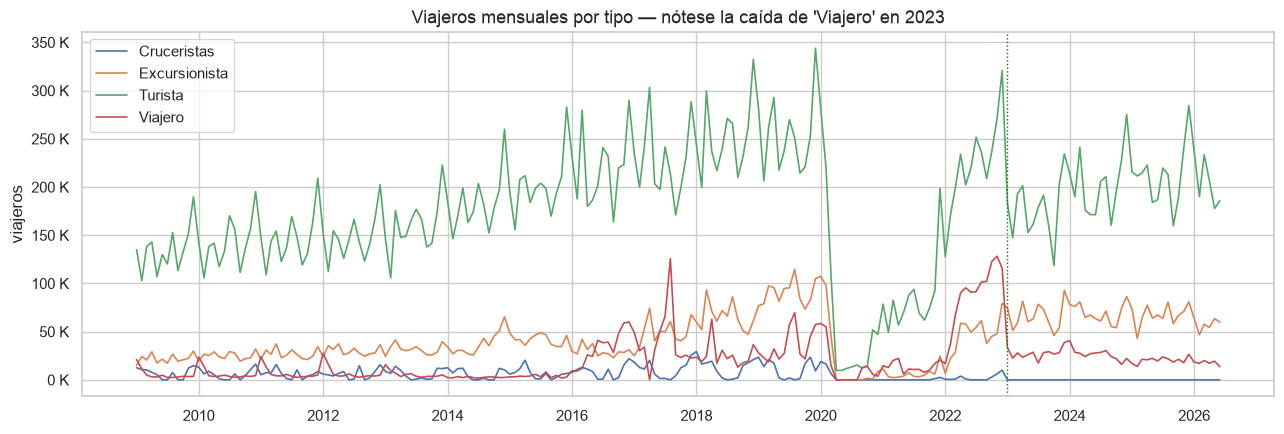

Total acumulado por tipo de viajero:
Tipo de Viajero
Turista         37,642,728.55
Excursionista    9,069,184.34
Viajero          4,471,622.21
Cruceristas      1,104,402.00
Name: Viajero, dtype: float64


In [11]:
comp = df.pivot_table(index="Fecha", columns="Tipo de Viajero",
                      values="Viajero", aggfunc="sum").fillna(0)

fig, ax = plt.subplots(figsize=(13, 4.5))
for col in comp.columns:
    ax.plot(comp.index, comp[col], label=col, lw=1.2)
ax.axvline(pd.Timestamp("2023-01-01"), color="green", ls=":", lw=1)
ax.set_title("Viajeros mensuales por tipo — nótese la caída de 'Viajero' en 2023")
ax.set_ylabel("viajeros"); ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f} K"))
plt.tight_layout(); plt.show()

# Aporte acumulado de cada tipo
print("Total acumulado por tipo de viajero:")
print(df.groupby("Tipo de Viajero")["Viajero"].sum().sort_values(ascending=False))

**Interpretación (tipo).** La curva de **"Viajero"** se desploma tras la línea de 2023 (verde) sin
que sea una caída real de turismo, mientras que **Turista** y **Excursionista** mantienen su patrón
estacional continuo. Esto confirma la decisión metodológica: la **serie total** del laboratorio se
define como `Turista + Excursionista`.

## 5. Países con mayor cantidad de viajeros

*(Requisito 1b.)* Ranking por **total acumulado** en todo el período (criterio que pide el
enunciado para elegir el Top-3, no un año específico).

Top 10 países / agrupaciones por viajeros acumulados:
País
El Salvador                 16,213,975.46
Guatemala                   14,792,331.35
Estados Unidos de América    7,047,842.96
Honduras                     2,788,232.82
México                       1,808,945.78
Belice                       1,328,255.77
Nicaragua                    1,164,342.73
Cruceristas                  1,078,372.00
Costa Rica                     882,179.75
Colombia                       561,035.32
Name: Viajero, dtype: float64


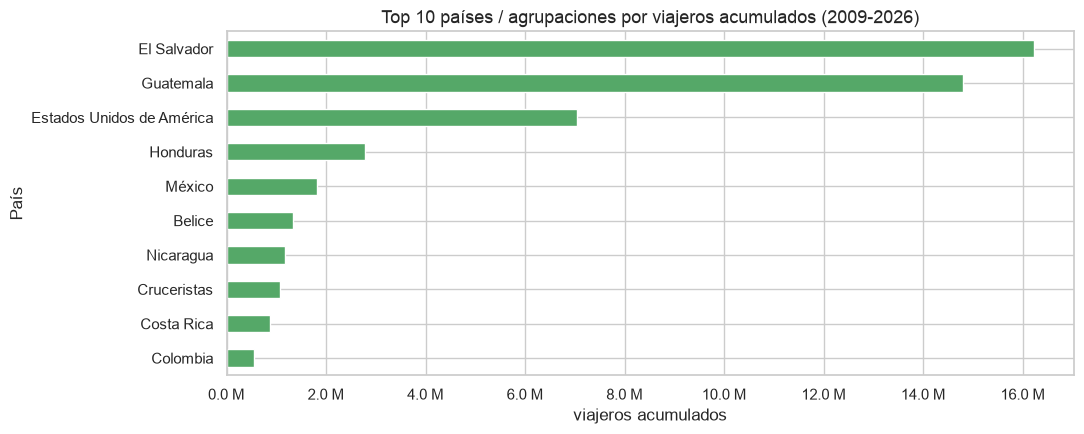

In [12]:
top_paises = (df.groupby("País")["Viajero"].sum()
                .sort_values(ascending=False))
print("Top 10 países / agrupaciones por viajeros acumulados:")
print(top_paises.head(10))

fig, ax = plt.subplots(figsize=(11, 4.5))
top_paises.head(10).iloc[::-1].plot(kind="barh", color="#55a868", ax=ax)
ax.set_title("Top 10 países / agrupaciones por viajeros acumulados (2009-2026)")
ax.set_xlabel("viajeros acumulados")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.1f} M"))
plt.tight_layout(); plt.show()

> **Nota** sobre el Top-3 de países: recuérdese el cambio de granularidad desde 2023 (país →
> agrupación de mercado). Los mercados grandes (El Salvador, EE. UU., Honduras, México…) siguen
> siendo comparables como serie; lo tendremos en cuenta al construir las series por país en la
> entrega final.

## 6. Regiones con mayor cantidad de viajeros

*(Requisito 1c.)* Usamos `Región dos` (continentes / grandes áreas), que es la variable que pide
el enunciado para la categoría de regiones geográficas.

Región dos
América Del Centro            37,406,534.83
América Del Norte              9,383,035.37
Europa                         2,222,620.85
América Del Sur y el Caribe    1,447,949.65
Cruceristas                    1,078,372.00
Asia                             421,702.52
Oceanía                          140,047.19
Oriente Medio                    135,712.55
Cruceros                          26,030.00
Otros Paises Del Mundo            25,111.15
0                                    821.00
Name: Viajero, dtype: float64


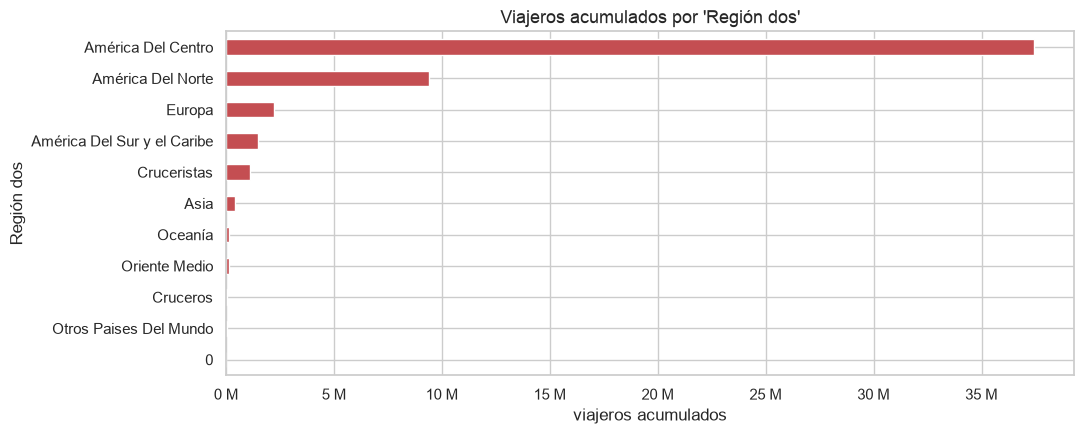

In [13]:
top_region = df.groupby("Región dos")["Viajero"].sum().sort_values(ascending=False)
print(top_region)

fig, ax = plt.subplots(figsize=(11, 4.5))
top_region.iloc[::-1].plot(kind="barh", color="#c44e52", ax=ax)
ax.set_title("Viajeros acumulados por 'Región dos'")
ax.set_xlabel("viajeros acumulados")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.0f} M"))
plt.tight_layout(); plt.show()

**Interpretación (regiones).** El mercado está **fuertemente concentrado en América**: *América
del Centro* domina por amplio margen (vecindad terrestre), seguida de *América del Norte* y
*Europa*. Este Top-3 sería la base de las series por región si se eligiera esa categoría.

## 7. Vías de ingreso y fronteras más utilizadas

*(Requisito 1d.)*

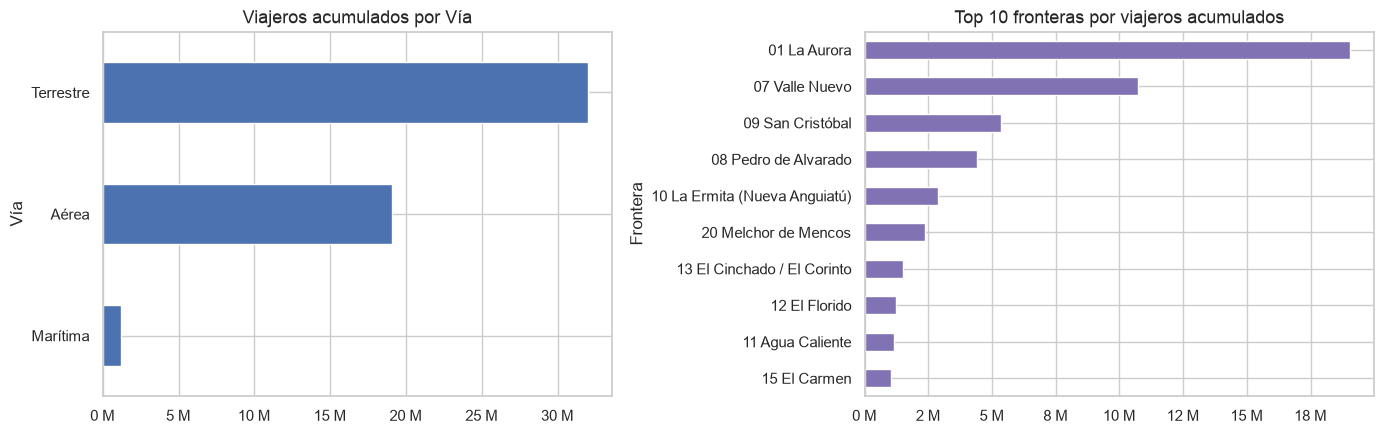

Participación por vía (%):
Vía
Terrestre   61.20
Aérea       36.50
Marítima     2.40
Name: Viajero, dtype: float64


In [14]:
via = df.groupby("Vía")["Viajero"].sum().sort_values(ascending=False)
frontera = df.groupby("Frontera")["Viajero"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
via.iloc[::-1].plot(kind="barh", color="#4c72b0", ax=ax[0])
ax[0].set_title("Viajeros acumulados por Vía")
ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.0f} M"))

frontera.head(10).iloc[::-1].plot(kind="barh", color="#8172b3", ax=ax[1])
ax[1].set_title("Top 10 fronteras por viajeros acumulados")
ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.0f} M"))
plt.tight_layout(); plt.show()

print("Participación por vía (%):")
print((via / via.sum() * 100).round(1))

**Interpretación (vías/fronteras).** La vía **Terrestre** concentra la mayor parte de los ingresos
(coherente con el peso de Centroamérica), seguida de la **Aérea** y, muy por detrás, la
**Marítima** (que además pierde detalle de registro desde 2017). Las fronteras terrestres con los
países vecinos y el aeropuerto La Aurora encabezan el ranking.

## 8. Patrón estacional y efecto de la pandemia

*(Requisito 1f y punto de la rúbrica: comportamiento durante y después de la pandemia.)*
Sobre la serie total consistente (`Turista + Excursionista`) vemos el patrón por mes y el impacto
de 2020.

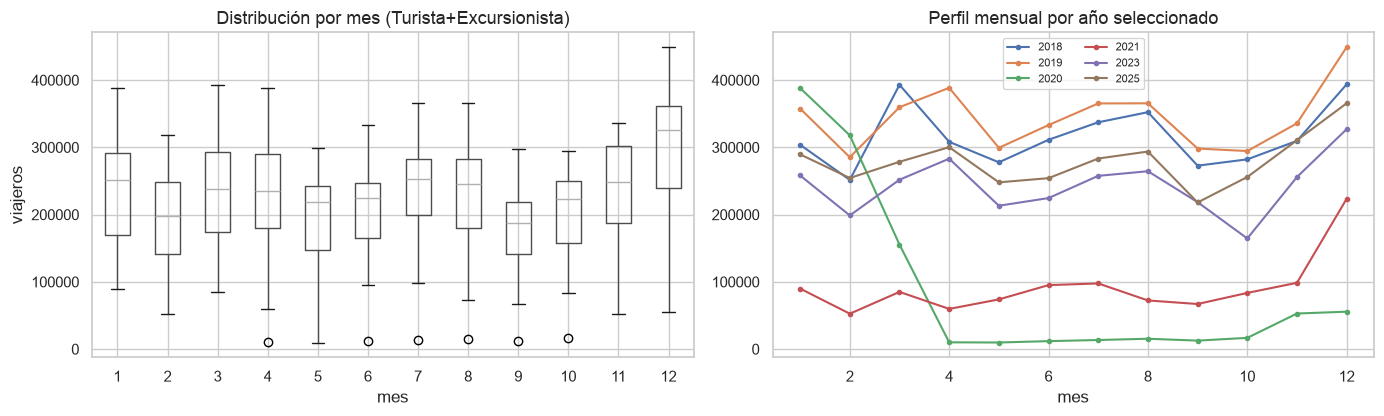

In [15]:
mask_te = df["Tipo de Viajero"].isin(["Turista", "Excursionista"])
serie_te = df[mask_te].groupby("Fecha")["Viajero"].sum()

tmp = serie_te.to_frame("v")
tmp["mes"] = tmp.index.month
tmp["anio"] = tmp.index.year

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
tmp.boxplot(column="v", by="mes", ax=ax[0])
ax[0].set_title("Distribución por mes (Turista+Excursionista)")
ax[0].set_xlabel("mes"); ax[0].set_ylabel("viajeros")

for anio in [2018, 2019, 2020, 2021, 2023, 2025]:
    sub = tmp[tmp["anio"] == anio]
    ax[1].plot(sub["mes"], sub["v"], marker=".", label=str(anio))
ax[1].set_title("Perfil mensual por año seleccionado")
ax[1].set_xlabel("mes"); ax[1].legend(ncol=2, fontsize=8)
plt.suptitle(""); plt.tight_layout(); plt.show()

In [16]:
# Cuantificamos el golpe de la pandemia: 2020-2021 vs 2019
base_2019 = serie_te[serie_te.index.year == 2019].sum()
for a in [2020, 2021, 2022, 2023]:
    tot = serie_te[serie_te.index.year == a].sum()
    print(f"{a}: {tot/base_2019*100:5.1f}% del nivel de 2019")

2020:  25.6% del nivel de 2019
2021:  26.6% del nivel de 2019
2022:  78.1% del nivel de 2019
2023:  70.6% del nivel de 2019


**Interpretación (estacionalidad + pandemia).** Existe un patrón estacional recurrente (meses altos
asociados a temporadas de viaje). La **pandemia** provocó una caída abrupta en 2020 hasta un piso
cercano a un cuarto del nivel de 2019, con recuperación progresiva en 2022–2023. Esto será clave
para el modelado: 2020–2021 es un tramo atípico que puede afectar tendencia y estacionalidad.

## 9. Resumen del EDA

- **Cobertura**: 210 meses consecutivos sin huecos (ene-2009 a jun-2026); 2026 es parcial.
- **Calidad**: sin nulos, sin duplicados, sin negativos; `Viajero` es una medida continua asimétrica.
- **Mercados**: fuerte concentración en América (Centro y Norte) y en la vía **Terrestre**.
- **Quiebres a tener presentes**: pandemia (2020), quiebre metodológico 2023 (→ usar
  `Turista+Excursionista`), cambio de granularidad de `País` desde 2023, y pérdida de detalle de la
  vía Marítima desde 2017.

Con esto pasamos al **análisis preliminar de dos series de tiempo**.